# Mobil Strateji Oyunlari - Kesifsel Veri Analizi (EDA)

Bu not defterinin amaci, tek/cift degiskenli analiz, eksik veri raporu ve betimsel istatistik tekniklerini bir mobil oyun kataloğu uzerinde uygulamaktir.

**Kullanilan veri seti (Kaggle):** `tristan581/17k-apple-app-store-strategy-games` - 17.000+ mobil strateji oyunu; puan, fiyat, boyut, yas siniri, tur (genre) gibi hem sayisal hem kategorik kolonlar icerir. Sayisal + kategorik karisik, coklu degisken yapisina sahip oldugu icin listedeki 9 veri setinden bu tercih edildi.

In [1]:
# temel veri isleme kutuphaneleri
import pandas as pd
import numpy as np

# gorsellestirme kutuphaneleri
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# istatistik kutuphaneleri
from scipy import stats
import warnings

# ayarlar
warnings.filterwarnings('ignore')  # uyari mesajlarini kapatir
pd.set_option('display.max_columns', 50)  # buyuk veride kolon sayisini sinirlar
pd.set_option('display.max_rows', None)  # satiri sinirlamaz
pd.set_option('display.float_format', lambda x: '%.2f' % x)  # virgulden sonra kac basamak

# grafik stili ayarlari
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print('Tum kutuphaneler basariyla yuklendi')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')
print(f'Seaborn version: {sns.__version__}')

Tum kutuphaneler basariyla yuklendi
Pandas version: 3.0.0
Numpy version: 2.3.2
Seaborn version: 0.13.2


## Veri Setini Yukleme

ÖĞRENME NOTU (yönlendirme): Veriyi Kaggle'dan `kagglehub` ile indirip okuyoruz - bu yuzden once Kaggle kimlik dogrulamasi (kaggle.json) yapman gerekir: https://www.kaggle.com/settings -> 'Create New Token'.

In [2]:
import os
import kagglehub

dataset_path = kagglehub.dataset_download('tristan581/17k-apple-app-store-strategy-games')
print('Veri seti yolu:', dataset_path)

csv_files = [f for f in os.listdir(dataset_path) if f.lower().endswith('.csv')]
data_path = os.path.join(dataset_path, csv_files[0])
print('Kullanilacak dosya:', data_path)

df = pd.read_csv(data_path)

  0%|          | 0.00/8.42M [00:00<?, ?B/s]

 12%|█▏        | 1.00M/8.42M [00:00<00:05, 1.32MB/s]

 24%|██▎       | 2.00M/8.42M [00:00<00:02, 2.64MB/s]

 47%|████▋     | 4.00M/8.42M [00:01<00:00, 5.61MB/s]

 95%|█████████▍| 8.00M/8.42M [00:01<00:00, 11.8MB/s]

100%|██████████| 8.42M/8.42M [00:01<00:00, 7.49MB/s]

Extracting files...


Veri seti yolu: C:\Users\dragon\.cache\kagglehub\datasets\tristan581\17k-apple-app-store-strategy-games\versions\3
Kullanilacak dosya: C:\Users\dragon\.cache\kagglehub\datasets\tristan581\17k-apple-app-store-strategy-games\versions\3\appstore_games.csv


In [3]:
# ozellik muhendisligi: sayisal bir yas kolonu elde etmek icin
# 'Age Rating' kolonundaki '+' isaretini kaldirip sayiya ceviriyoruz (ornek: '12+' -> 12)
df['Age_Rating_Numeric'] = df['Age Rating'].astype(str).str.replace('+', '', regex=False)
df['Age_Rating_Numeric'] = pd.to_numeric(df['Age_Rating_Numeric'], errors='coerce')

# boyut bilgisini (byte) MB'a cevir - okunmasi daha kolay
df['Size_MB'] = df['Size'] / (1024 * 1024)

# oyun icinde satin alma var mi (ikili kategori)
df['Has_In_App_Purchases'] = np.where(df['In-app Purchases'].notna(), 'Yes', 'No')

df.head()

,URL,ID,Name,Subtitle,Icon URL,Average User Rating,User Rating Count,Price,In-app Purchases,Description,Developer,Age Rating,Languages,Size,Primary Genre,Genres,Original Release Date,Current Version Release Date,Age_Rating_Numeric,Size_MB,Has_In_App_Purchases
0,https://apps.apple.com/us/app/sudoku/id284921427,284921427,Sudoku,NaN,https://is2-ssl.mzstatic.com/image/thumb/Purpl...,4.00,3553.00,2.99,NaN,"Join over 21,000,000 of our fans and download ...",Mighty Mighty Good Games,4+,"DA, NL, EN, FI, FR, DE, IT, JA, KO, NB, PL, PT...",15853568.00,Games,"Games, Strategy, Puzzle",11/07/2008,30/05/2017,4,15.12,No
1,https://apps.apple.com/us/app/reversi/id284926400,284926400,Reversi,NaN,https://is4-ssl.mzstatic.com/image/thumb/Purpl...,3.50,284.00,1.99,NaN,"The classic game of Reversi, also known as Oth...",Kiss The Machine,4+,EN,12328960.00,Games,"Games, Strategy, Board",11/07/2008,17/05/2018,4,11.76,No
2,https://apps.apple.com/us/app/morocco/id284946595,284946595,Morocco,NaN,https://is5-ssl.mzstatic.com/image/thumb/Purpl...,3.00,8376.00,0.00,NaN,Play the classic strategy game Othello (also k...,Bayou Games,4+,EN,674816.00,Games,"Games, Board, Strategy",11/07/2008,5/09/2017,4,0.64,No
3,https://apps.apple.com/us/app/sudoku-free/id28...,285755462,Sudoku (Free),NaN,https://is3-ssl.mzstatic.com/image/thumb/Purpl...,3.50,190394.00,0.00,NaN,"Top 100 free app for over a year.\nRated ""Best...",Mighty Mighty Good Games,4+,"DA, NL, EN, FI, FR, DE, IT, JA, KO, NB, PL, PT...",21552128.00,Games,"Games, Strategy, Puzzle",23/07/2008,30/05/2017,4,20.55,No
4,https://apps.apple.com/us/app/senet-deluxe/id2...,285831220,Senet Deluxe,NaN,https://is1-ssl.mzstatic.com/image/thumb/Purpl...,3.50,28.00,2.99,NaN,"""Senet Deluxe - The Ancient Game of Life and A...",RoGame Software,4+,"DA, NL, EN, FR, DE, EL, IT, JA, KO, NO, PT, RU...",34689024.00,Games,"Games, Strategy, Board, Education",18/07/2008,22/07/2018,4,33.08,No


In [4]:
# rastgele bes satir
df.sample(5)

,URL,ID,Name,Subtitle,Icon URL,Average User Rating,User Rating Count,Price,In-app Purchases,Description,Developer,Age Rating,Languages,Size,Primary Genre,Genres,Original Release Date,Current Version Release Date,Age_Rating_Numeric,Size_MB,Has_In_App_Purchases
7087,https://apps.apple.com/us/app/mini-chess-quick...,1048990809,Mini Chess (Quick Chess),Classic Strategy Board Games,https://is5-ssl.mzstatic.com/image/thumb/Purpl...,4.50,157.00,0.00,NaN,The traditional game of chess made easier and ...,OutOfTheBit Ltd,4+,"EN, IT",41309184.00,Games,"Games, Strategy, Education, Board",15/12/2015,25/05/2018,4,39.40,No
16967,https://apps.apple.com/us/app/glow-hockey-stri...,1473680543,Glow Hockey Strike,Best 2 player air hockey game,https://is2-ssl.mzstatic.com/image/thumb/Purpl...,5.00,5.00,0.00,NaN,Glow Hockey Strike is a cool colorful air hock...,Samir Jabeur,4+,EN,128687104.00,Games,"Games, Simulation, Strategy",28/07/2019,28/07/2019,4,122.73,No
2207,https://apps.apple.com/us/app/numbers-game-6-n...,641762250,Numbers Game! - 6 Number Math Puzzle Game and ...,NaN,https://is5-ssl.mzstatic.com/image/thumb/Purpl...,4.00,11.00,0.00,"0.99, 8.99, 1.99, 3.99","Numbers Game! is a simple, yet highly addictiv...",ROOT38 LIMITED,4+,"AR, CA, CS, DA, NL, EN, FI, FR, DE, EL, HE, HU...",39395328.00,Games,"Games, Education, Puzzle, Strategy",21/06/2013,19/03/2015,4,37.57,Yes
2606,https://apps.apple.com/us/app/when-in-rome/id7...,702758540,When In Rome,NaN,https://is3-ssl.mzstatic.com/image/thumb/Purpl...,3.50,19.00,0.00,NaN,"""Realore introduces a brand new strategy game ...",Qumaron,4+,"NL, EN, FR, DE, IT, JA, KO, PT, RU, ES, SV",246755328.00,Games,"Games, Simulation, Entertainment, Strategy",11/12/2013,11/12/2013,4,235.32,No
15427,https://apps.apple.com/us/app/bizbattle-royale...,1440267945,BizBattle Royale,1-8 Player Business Simulation,https://is2-ssl.mzstatic.com/image/thumb/Purpl...,NaN,NaN,0.00,"1.99, 7.99, 4.99, 10.99",BizBattle Royale - Multiplayer Business Simula...,IndustryMasters Limited,4+,EN,19776512.00,Games,"Games, Simulation, Strategy, Education",31/10/2018,27/07/2019,4,18.86,Yes


In [5]:
print('Veri tipleri')
print('=' * 40)
dtype_df = pd.DataFrame({
    'sutun': df.columns,
    'veri tipi': df.dtypes.values,
    'null degeri': df.isnull().sum().values,
    'null orani(%)': (df.isnull().sum().values / len(df) * 100).round(2),
    'unique': df.nunique().values
})

print(dtype_df.to_string(index=False))

Veri tipleri
                       sutun veri tipi  null degeri  null orani(%)  unique
                         URL       str            0           0.00   16847
                          ID     int64            0           0.00   16847
                        Name       str            0           0.00   16847
                    Subtitle       str        11746          69.07    5010
                    Icon URL       str            0           0.00   16847
         Average User Rating   float64         9446          55.54       9
           User Rating Count   float64         9446          55.54    1792
                       Price   float64           24           0.14      24
            In-app Purchases       str         9324          54.82    3803
                 Description       str            0           0.00   16473
                   Developer       str            0           0.00    8693
                  Age Rating       str            0           0.00       4
            

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17007 entries, 0 to 17006
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   URL                           17007 non-null  str    
 1   ID                            17007 non-null  int64  
 2   Name                          17007 non-null  str    
 3   Subtitle                      5261 non-null   str    
 4   Icon URL                      17007 non-null  str    
 5   Average User Rating           7561 non-null   float64
 6   User Rating Count             7561 non-null   float64
 7   Price                         16983 non-null  float64
 8   In-app Purchases              7683 non-null   str    
 9   Description                   17007 non-null  str    
 10  Developer                     17007 non-null  str    
 11  Age Rating                    17007 non-null  str    
 12  Languages                     16947 non-null  str    
 13  Size        

In [7]:
df.shape

(17007, 21)

In [8]:
# sayisal degiskenlerle ilgili temel istatistikler
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,17007.00,1059613815.45,299967589.36,284921427.00,899654330.00,1112286228.00,1286982837.00,1475076711.00
Average User Rating,7561.00,4.06,0.75,1.00,3.50,4.50,4.50,5.00
User Rating Count,7561.00,3306.53,42322.56,5.00,12.00,46.00,309.00,3032734.00
Price,16983.00,0.81,7.84,0.00,0.00,0.00,0.00,179.99
Size,17006.00,115706429.89,203647677.85,51328.00,22950144.00,56768954.00,133027072.00,4005591040.00
Age_Rating_Numeric,17007.00,6.20,3.62,4.00,4.00,4.00,9.00,17.00
Size_MB,17006.00,110.35,194.21,0.05,21.89,54.14,126.86,3820.03


In [9]:
# degisken turlerini ayir
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
print('Sayisal kolonlar:', list(numeric_columns))
print('Kategorik kolonlar:', list(categorical_columns))

Sayisal kolonlar: ['ID', 'Average User Rating', 'User Rating Count', 'Price', 'Size', 'Age_Rating_Numeric', 'Size_MB']
Kategorik kolonlar: ['URL', 'Name', 'Subtitle', 'Icon URL', 'In-app Purchases', 'Description', 'Developer', 'Age Rating', 'Languages', 'Primary Genre', 'Genres', 'Original Release Date', 'Current Version Release Date', 'Has_In_App_Purchases']


In [10]:
missing_values = df.isnull().sum()
missing_rate = (missing_values / len(df) * 100).round(2)
missing_df = pd.concat([missing_values, missing_rate], axis=1)
missing_df.columns = ['missing_count', 'missing_rate']
missing_df = missing_df.sort_values('missing_rate', ascending=False)

missing_df

,missing_count,missing_rate
Subtitle,11746,69.07
User Rating Count,9446,55.54
Average User Rating,9446,55.54
In-app Purchases,9324,54.82
Languages,60,0.35
Price,24,0.14
Size,1,0.01
Size_MB,1,0.01
URL,0,0.00
Icon URL,0,0.00


ÖĞRENME NOTU: Bu mobil oyun veri setinde ozellikle `Average User Rating` ve `User Rating Count` kolonlarinda eksik deger bekleniyor (henuz yeterli oy almamis oyunlar) - bu, gercek dunya verisinin tipik bir ornegidir.

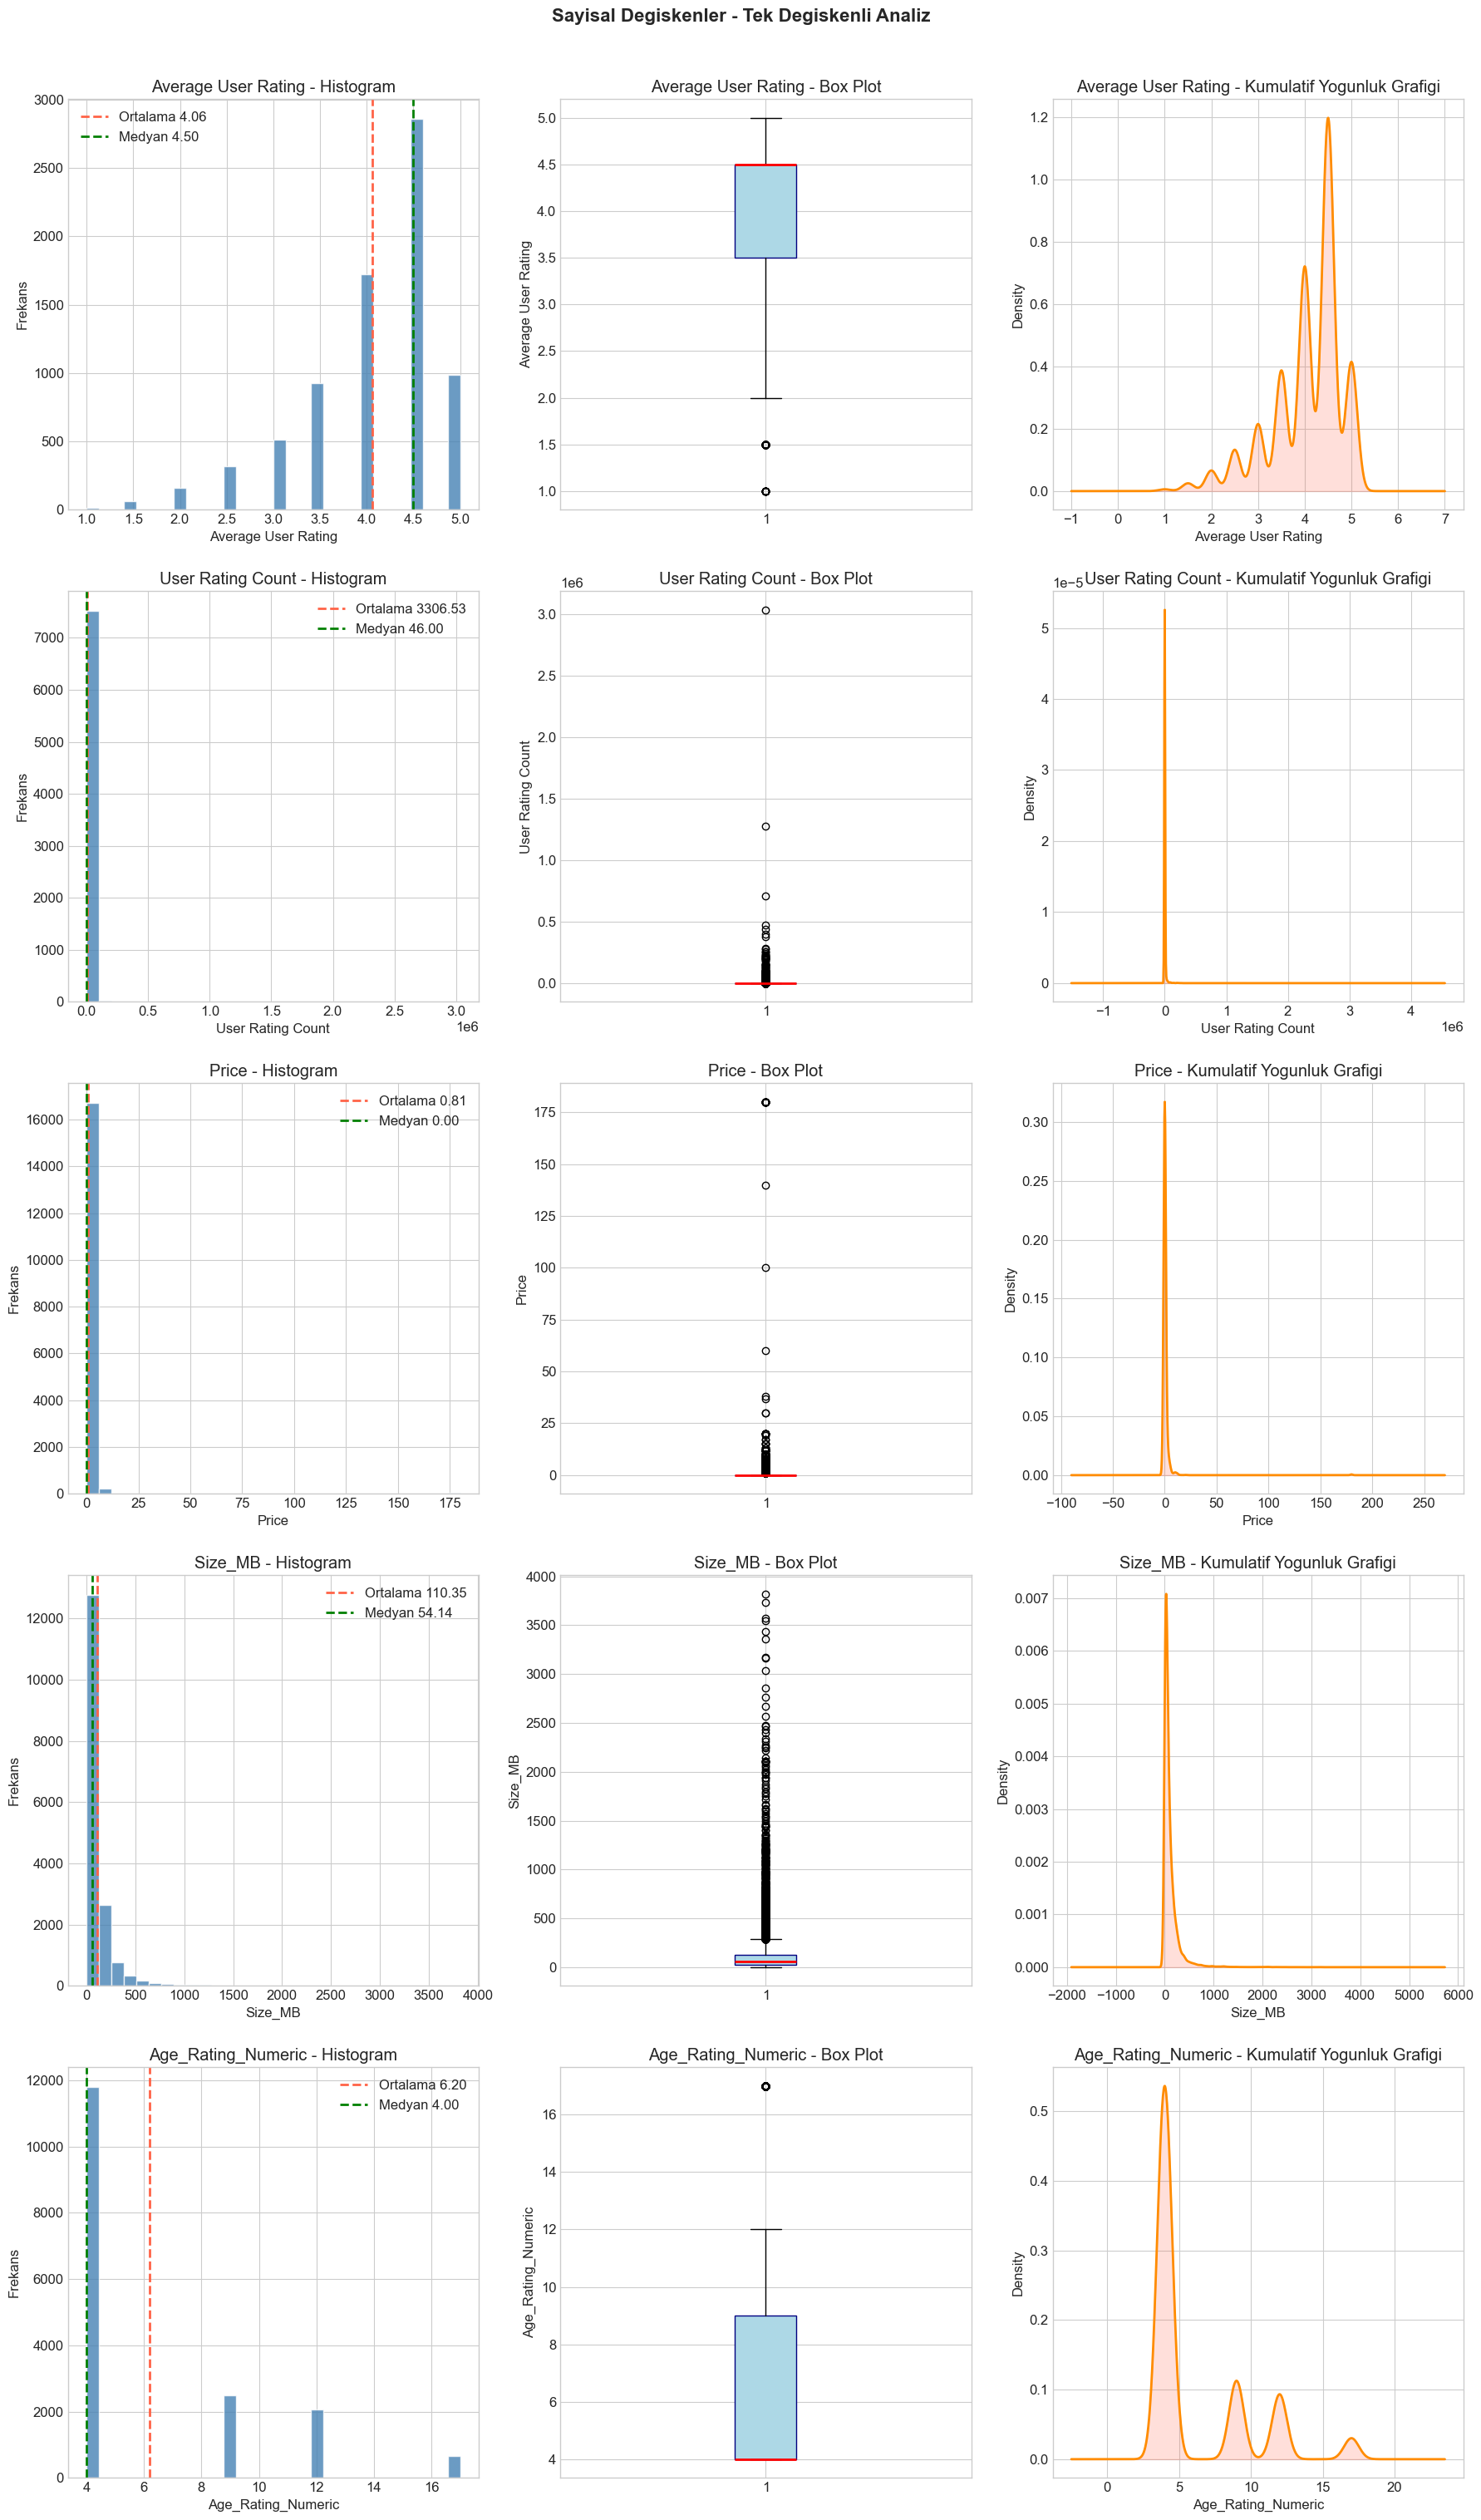

In [11]:
# sayisal degiskenler - tek degiskenli analiz (histogram + box plot + yogunluk grafigi)
numeric_cols_to_plot = ['Average User Rating', 'User Rating Count', 'Price', 'Size_MB', 'Age_Rating_Numeric']

fig, axes = plt.subplots(len(numeric_cols_to_plot), 3, figsize=(18, 6 * len(numeric_cols_to_plot)))

for i, col in enumerate(numeric_cols_to_plot):
    data = df[col].dropna()

    axes[i, 0].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 0].axvline(data.mean(), color='tomato', linestyle='dashed', linewidth=2, label=f'Ortalama {data.mean():.2f}')
    axes[i, 0].axvline(data.median(), color='green', linestyle='dashed', linewidth=2, label=f'Medyan {data.median():.2f}')
    axes[i, 0].set_title(f'{col} - Histogram')
    axes[i, 0].legend()
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frekans')

    axes[i, 1].boxplot(data, vert=True, patch_artist=True,
                        boxprops=dict(facecolor='lightblue', color='navy'),
                        medianprops=dict(color='red', linewidth=2))
    axes[i, 1].set_title(f'{col} - Box Plot')
    axes[i, 1].set_ylabel(col)

    data.plot.kde(ax=axes[i, 2], color='darkorange', linewidth=2)
    axes[i, 2].fill_between(axes[i, 2].lines[0].get_xdata(),
                             axes[i, 2].lines[0].get_ydata(),
                             color='tomato', alpha=0.2)
    axes[i, 2].set_title(f'{col} - Kumulatif Yogunluk Grafigi')
    axes[i, 2].set_xlabel(col)

plt.suptitle('Sayisal Degiskenler - Tek Degiskenli Analiz', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [12]:
# istatistiksel ozet tablo
print('Sayisal Degiskenler Detayli Istatistikler:')
print('=' * 70)

for col in numeric_cols_to_plot:
    data = df[col].dropna()
    print(f'\n* {col.upper()}')
    print(f'Ortalama: {data.mean():.2f}')
    print(f'Medyan: {data.median():.2f}')
    print(f'Standart Sapma: {data.std():.2f}')
    print(f'Minimum: {data.min():.2f}')
    print(f'Maksimum: {data.max():.2f}')
    print(f'Varyans: {data.var():.2f}')
    print(f'Skewness (Carpiklik): {data.skew():.2f}')
    print(f'Kurtosis (Basiklik): {data.kurtosis():.2f}')
    print(f'IQR: {data.quantile(0.75) - data.quantile(0.25):.2f}')
    print('=' * 70)

Sayisal Degiskenler Detayli Istatistikler:

* AVERAGE USER RATING
Ortalama: 4.06
Medyan: 4.50
Standart Sapma: 0.75
Minimum: 1.00
Maksimum: 5.00
Varyans: 0.56
Skewness (Carpiklik): -1.16
Kurtosis (Basiklik): 1.22
IQR: 1.00

* USER RATING COUNT
Ortalama: 3306.53
Medyan: 46.00
Standart Sapma: 42322.56
Minimum: 5.00
Maksimum: 3032734.00
Varyans: 1791199128.15
Skewness (Carpiklik): 53.71
Kurtosis (Basiklik): 3598.57
IQR: 297.00

* PRICE
Ortalama: 0.81
Medyan: 0.00
Standart Sapma: 7.84
Minimum: 0.00
Maksimum: 179.99
Varyans: 61.40
Skewness (Carpiklik): 21.65
Kurtosis (Basiklik): 487.86
IQR: 0.00

* SIZE_MB
Ortalama: 110.35
Medyan: 54.14
Standart Sapma: 194.21
Minimum: 0.05
Maksimum: 3820.03
Varyans: 37718.91
Skewness (Carpiklik): 7.17
Kurtosis (Basiklik): 82.67
IQR: 104.98

* AGE_RATING_NUMERIC
Ortalama: 6.20
Medyan: 4.00
Standart Sapma: 3.62
Minimum: 4.00
Maksimum: 17.00
Varyans: 13.13
Skewness (Carpiklik): 1.44
Kurtosis (Basiklik): 1.02
IQR: 5.00


## Kategorik Kolonlar

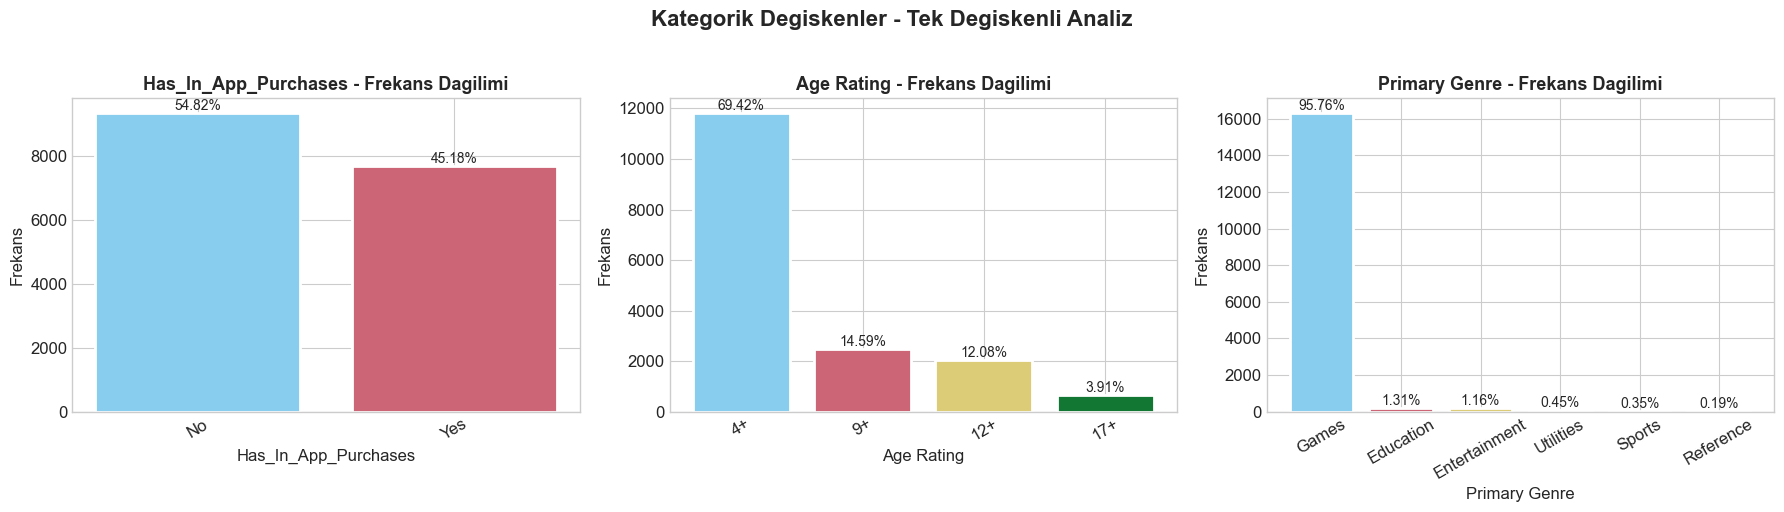

In [13]:
categorical_cols_to_plot = ['Has_In_App_Purchases', 'Age Rating', 'Primary Genre']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

colors = ['#88CCEE', '#CC6677', '#DDCC77', '#117733', '#332288', '#AA4499']
for i, col in enumerate(categorical_cols_to_plot):
    # Primary Genre gibi yuksek kardinaliteli kolonlar icin en populer ilk 6 degeri al
    counts = df[col].value_counts().head(6)
    pct = (counts / len(df) * 100).round(2)

    bars = axes[i].bar(counts.index.astype(str), counts.values,
                        color=colors[:len(counts)], edgecolor='white', linewidth=2)

    axes[i].set_title(f'{col} - Frekans Dagilimi', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekans')
    axes[i].tick_params(axis='x', rotation=30)

    for bar, p in zip(bars, pct.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                      bar.get_height() + 1,
                      f'{p}%', ha='center', va='bottom', fontsize=10)

plt.suptitle('Kategorik Degiskenler - Tek Degiskenli Analiz', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# 17+ yas sinirli oyunlarin turlere gore dagilimi
mature_games = df[df['Age Rating'] == '17+']
print('Toplam 17+ oyun sayisi:', len(mature_games))
print(mature_games['Primary Genre'].value_counts().head())

Toplam 17+ oyun sayisi: 665
Primary Genre
Games            615
Sports            16
Entertainment     13
Education          7
Reference          3
Name: count, dtype: int64


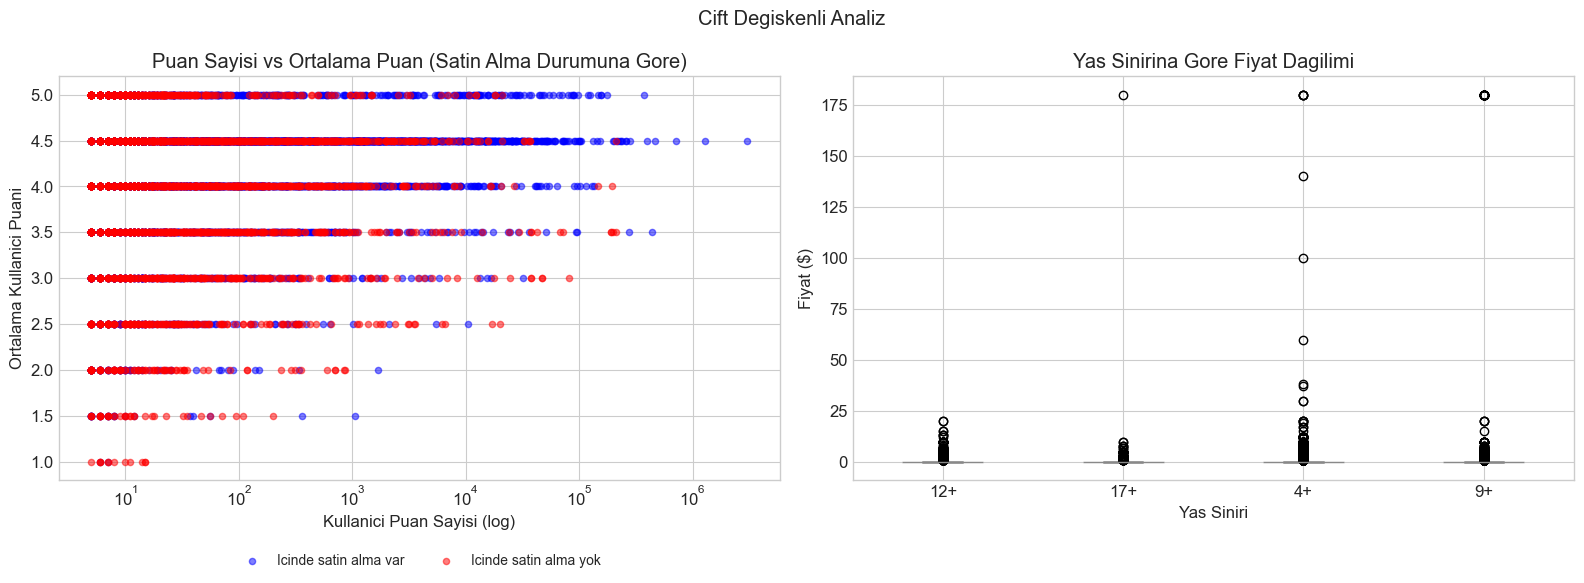

In [15]:
# sayisal vs sayisal: Scatter Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

with_purchase = df[df['Has_In_App_Purchases'] == 'Yes']
without_purchase = df[df['Has_In_App_Purchases'] == 'No']

axes[0].scatter(with_purchase['User Rating Count'], with_purchase['Average User Rating'],
                color='blue', label='Icinde satin alma var', alpha=0.5, s=20)
axes[0].scatter(without_purchase['User Rating Count'], without_purchase['Average User Rating'],
                color='red', label='Icinde satin alma yok', alpha=0.5, s=20)
axes[0].set_xscale('log')
axes[0].set_xlabel('Kullanici Puan Sayisi (log)')
axes[0].set_ylabel('Ortalama Kullanici Puani')
axes[0].set_title('Puan Sayisi vs Ortalama Puan (Satin Alma Durumuna Gore)')
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, framealpha=0.9, fontsize=10)

df.boxplot(column='Price', by='Age Rating', ax=axes[1], patch_artist=True)
axes[1].set_xlabel('Yas Siniri')
axes[1].set_ylabel('Fiyat ($)')
axes[1].set_title('Yas Sinirina Gore Fiyat Dagilimi')

plt.suptitle('Cift Degiskenli Analiz')
plt.tight_layout()
plt.show()

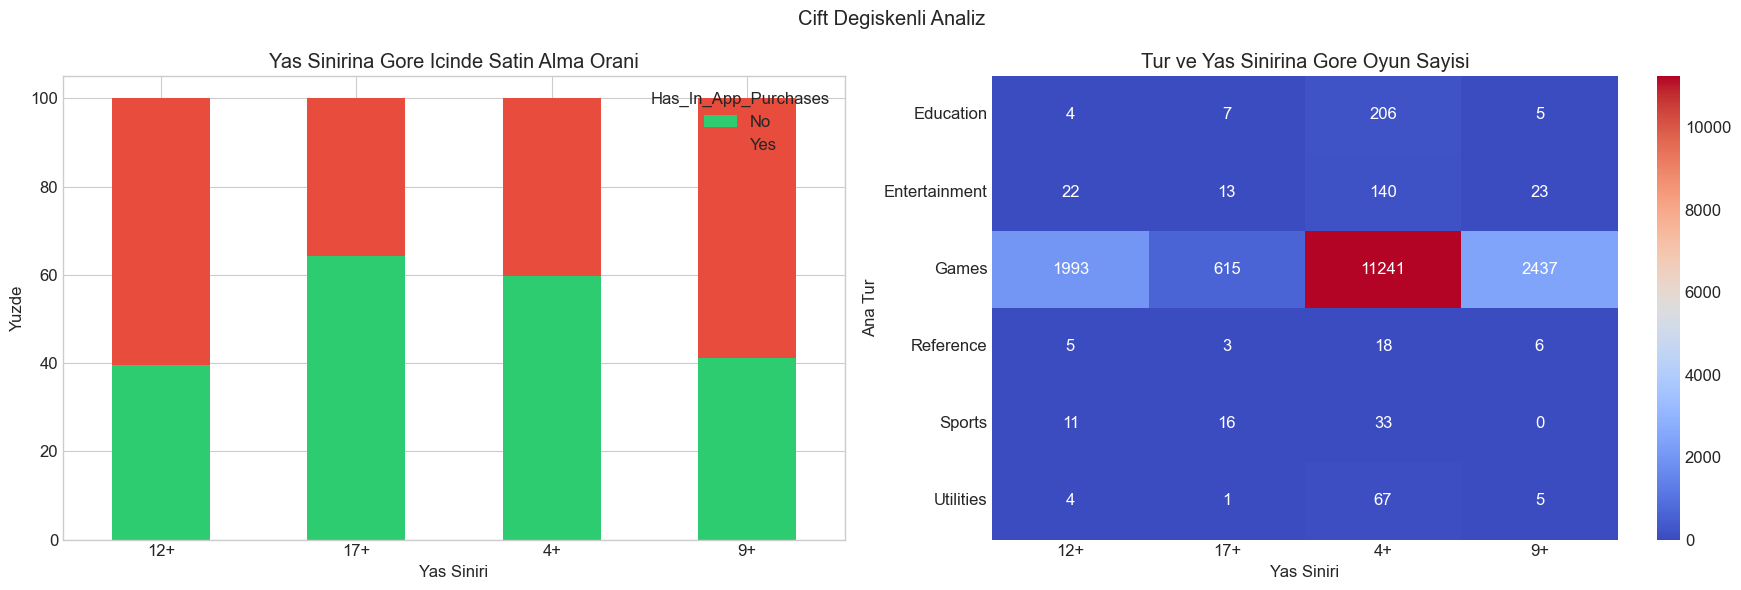

In [16]:
# kategorik vs kategorik: crosstab + heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ct_pct = pd.crosstab(df['Age Rating'], df['Has_In_App_Purchases'], normalize='index') * 100
ct_pct.plot(kind='bar', stacked=True, ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Yas Sinirina Gore Icinde Satin Alma Orani')
axes[0].set_xlabel('Yas Siniri')
axes[0].set_ylabel('Yuzde')
axes[0].tick_params(axis='x', rotation=0)

top_genres = df['Primary Genre'].value_counts().head(6).index
ct2 = pd.crosstab(df[df['Primary Genre'].isin(top_genres)]['Primary Genre'], df['Age Rating'])
sns.heatmap(ct2, annot=True, fmt='d', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Tur ve Yas Sinirina Gore Oyun Sayisi')
axes[1].set_xlabel('Yas Siniri')
axes[1].set_ylabel('Ana Tur')

plt.suptitle('Cift Degiskenli Analiz')
plt.tight_layout()
plt.show()

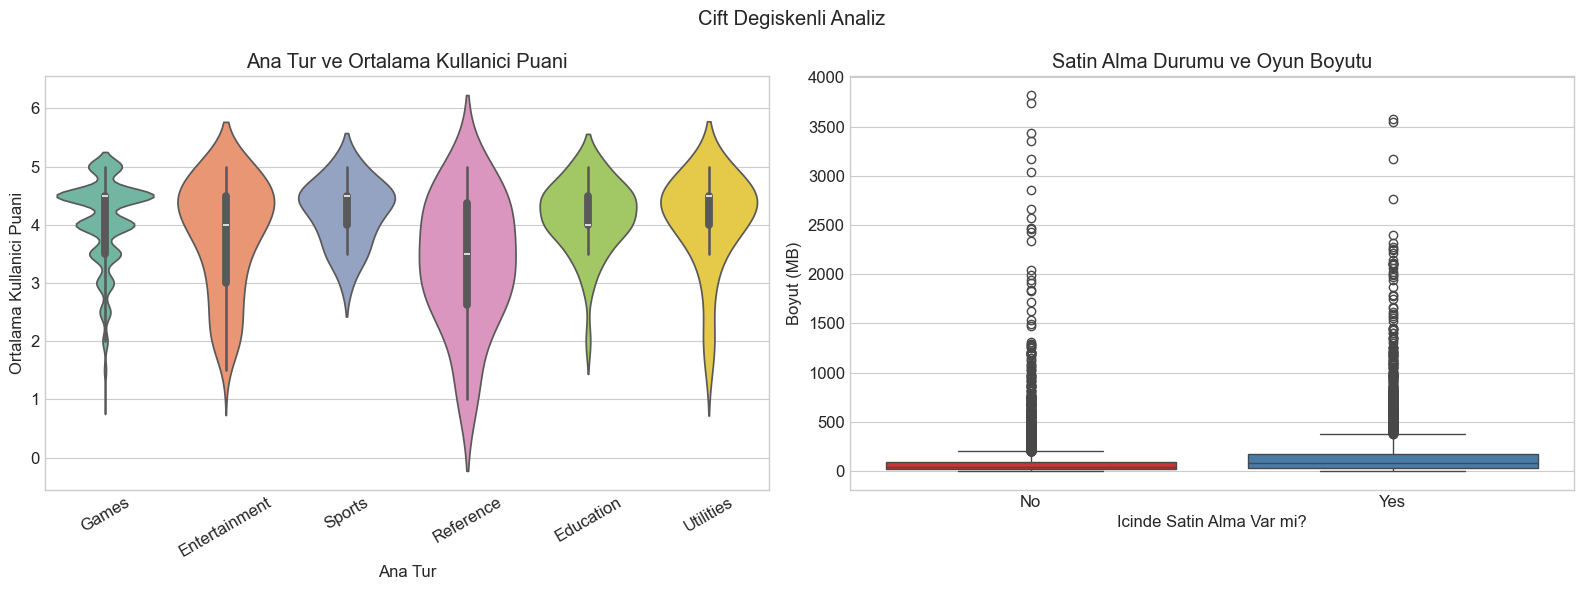

In [17]:
# kategorik vs sayisal: violin + box plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_genres_list = df['Primary Genre'].value_counts().head(6).index
subset = df[df['Primary Genre'].isin(top_genres_list)]

sns.violinplot(data=subset, x='Primary Genre', y='Average User Rating', ax=axes[0], palette='Set2')
axes[0].set_title('Ana Tur ve Ortalama Kullanici Puani')
axes[0].set_xlabel('Ana Tur')
axes[0].set_ylabel('Ortalama Kullanici Puani')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='Has_In_App_Purchases', y='Size_MB', ax=axes[1], palette='Set1')
axes[1].set_title('Satin Alma Durumu ve Oyun Boyutu')
axes[1].set_xlabel('Icinde Satin Alma Var mi?')
axes[1].set_ylabel('Boyut (MB)')

plt.suptitle('Cift Degiskenli Analiz')
plt.tight_layout()
plt.show()